# Forecasting a nivel de evento (XGBoost)

En vez de trabajar a resolucion horaria fija, este notebook construye un
dataset donde cada fila es un **evento**: un cambio simultaneo en ambos
targets de laboratorio (`% Iron Concentrate` y `% Silica Concentrate`).

Motivacion: en el dataset horario, la mayoria de los "cambios" hora a hora
son en realidad el mismo valor de laboratorio repetido (el laboratorio no
mide cada hora exacta). Entre dos eventos reales de actualizacion de
concentrado, guardamos los estadisticos (media/std/pendiente) de las
variables de proceso durante esa ventana, en vez de un valor por hora que
mezcla tramos "congelados" con tramos de cambio real.

Se comprobo (ver celda de diagnostico) que en resolucion horaria el 98% de
los cambios de Iron Concentrate y Silica Concentrate ocurren en la misma
fila -> se usa cambio simultaneo en ambos como definicion de evento.

Solo se entrena XGBoost (sin LSTM, sin grid search extenso) para validar el
enfoque antes de invertir mas tiempo.

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [68]:
filepath = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'
TARGET = ['% Iron Concentrate', '% Silica Concentrate']  # columnas a predecir

df = pd.read_csv(filepath, decimal=',')
df['date'] = pd.to_datetime(df['date'])

# Columnas de laboratorio: se miden una vez por hora y aparecen repetidas en el CSV
# crudo en cada fila de 20s de esa hora (no son 180 medidas independientes).
lab_cols = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']
sensor_cols = [c for c in df.columns if c not in ['date'] + lab_cols]

In [69]:
# --- 1. Fix the Time Index (The Crucial Step) ---
# df.groupby('date').cumcount() counts the position of each duplicate (0 to 179)
# We multiply that position by 20 seconds and add it to the base timestamp
time_offsets = pd.to_timedelta(df.groupby('date').cumcount() * 20, unit='s')

# Build a precise timeline from the 'date' column + offset (the row index itself
# is just 0..N-1, it is not a datetime, so we cannot add timedeltas to it directly)
df.index = df['date'] + time_offsets

# --- 2. Filter the Bad Range ---
start_remove = '2017-03-10 01:00:00'
end_remove = '2017-03-29 11:01:00'

# Create mask and apply it
mask = (df.index < start_remove) | (df.index > end_remove)
df = df[mask]

# Drop the empty 19-day gap created by resampling
df = df.dropna()

In [70]:
# Limpieza de outliers por ventana
numeric_df = df.select_dtypes(include=[np.number])

# windowed outlier detection using rolling IQR
window_size = 180  # Adjust based on your signal's frequency

Q1_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.25)
Q3_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.75)
IQR_rolling = Q3_rolling - Q1_rolling

lower_bound_rolling = Q1_rolling - 1.5 * IQR_rolling
upper_bound_rolling = Q3_rolling + 1.5 * IQR_rolling

# En vez de descartar la fila entera cuando una sola columna se sale de rango,
# recortamos (winsorize) cada valor a su limite mas cercano: perdemos el valor
# extremo pero conservamos la fila y el resto de columnas de esa lectura.
n_outliers = ((numeric_df < lower_bound_rolling) | (numeric_df > upper_bound_rolling)).sum().sum()
df[numeric_df.columns] = numeric_df.clip(lower=lower_bound_rolling, upper=upper_bound_rolling, axis=0)

print(f"Row count: {len(df)}")
print(f"Valores recortados (winsorized): {n_outliers}")

Row count: 710639
Valores recortados (winsorized): 299428


In [71]:
# Promedia senales con alta correlacion
air_flow_6_7 = ['Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow']
air_flow_1_2_3 = ['Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow']
silica_iron_feed = ['% Iron Feed', '% Silica Feed']
level_4_5_6_7 = ['Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level']
level_1_2_3 = ['Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level']

df['Air Flow 6_7_Mean'] = df[air_flow_6_7].mean(axis=1)
df['Air Flow 1_2_3_Mean'] = df[air_flow_1_2_3].mean(axis=1)
df['Feed Iron_Silica_Mean'] = df[silica_iron_feed].mean(axis=1)
df['Level 4_5_6_7_Mean'] = df[level_4_5_6_7].mean(axis=1)
df['Level 1_2_3_Mean'] = df[level_1_2_3].mean(axis=1)

columns_to_drop = air_flow_6_7 + air_flow_1_2_3 + silica_iron_feed + level_4_5_6_7 + level_1_2_3
df = df.drop(columns=columns_to_drop)

# '% Iron Feed' y '% Silica Feed' se fusionaron en 'Feed Iron_Silica_Mean';
# actualizamos lab_cols para que siga reflejando las columnas de laboratorio reales.
lab_cols = [c for c in lab_cols if c not in silica_iron_feed] + ['Feed Iron_Silica_Mean']

# sensor_cols apuntaba a los nombres originales (antes de combinar columnas
# correlacionadas); lo recalculamos contra las columnas reales de df.
sensor_cols = [c for c in df.columns if c not in ['date'] + lab_cols]

print(f"df (resolucion 20s, post-limpieza): {df.shape}")

df (resolucion 20s, post-limpieza): (710639, 15)


## Agregacion horaria

Igual que en el notebook original: `df` (20s) se colapsa a una fila por hora
antes de detectar eventos. `lab_cols` usa `'first'` (todas las filas de la
hora ya comparten el mismo valor de laboratorio); `sensor_cols` usa `'mean'`
como resumen horario base. Detectar eventos y agregar ventanas sobre el
crudo de 20s sería incorrecto: cada valor de laboratorio aparece repetido
~180 veces dentro de la hora, así que un `diff()` sobre el crudo mezclaría
"cambios" espurios con eventos reales, y las ventanas de agregacion
arrastrarían miles de filas de sensores en vez de los puntos horarios que
de verdad separan un evento del siguiente.

In [72]:
agg_hourly = {c: 'first' for c in lab_cols}
agg_hourly.update({c: 'mean' for c in sensor_cols})
df_hourly = df.groupby('date', as_index=True).agg(agg_hourly).sort_index()

print(f"df_hourly (resolucion 1h): {df_hourly.shape}")

df_hourly (resolucion 1h): (3948, 14)


## Deteccion de eventos

Un evento se define sobre `df_hourly`: la ventana entre dos eventos
consecutivos se agrega sobre los puntos horarios que caen dentro de ella
(normalmente 1, hasta `GAP_MAX_HOURS`).

In [73]:
# Un evento = fila donde AMBOS targets cambian respecto a la fila anterior.
# Se comprobo que a resolucion horaria el 98% de los cambios de Iron y Silica
# Concentrate coinciden en la misma fila, asi que exigir cambio simultaneo no
# descarta apenas eventos reales y evita mezclar dos procesos de actualizacion
# de laboratorio distintos.
change_iron = df_hourly[TARGET[0]].diff() != 0
change_silica = df_hourly[TARGET[1]].diff() != 0
is_event = change_iron & change_silica
is_event.iloc[0] = False  # la primera fila no tiene "cambio" valido (no hay anterior)

event_rows = df_hourly.loc[is_event].copy()
print(f"Eventos detectados (cambio simultaneo en ambos targets): {len(event_rows)}")

event_gap_hours = event_rows.index.to_series().diff().dt.total_seconds() / 3600
print("Estadisticas de los gaps entre eventos:")
print(event_gap_hours.describe())

Eventos detectados (cambio simultaneo en ambos targets): 3474
Estadisticas de los gaps entre eventos:
count    3473.000000
mean        1.136193
std         1.704780
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        74.000000
Name: date, dtype: float64


## Features agregadas por ventana entre eventos

Para cada evento, agregamos las variables de proceso (`sensor_cols`) sobre
la ventana `(evento_anterior, evento_actual]` usando media, desviacion
estandar y pendiente (tendencia dentro de la ventana). El target es el valor
de laboratorio en el evento actual; `target_prev_*` es el valor de
laboratorio "fresco" en el evento anterior (naturalmente disponible en el
momento de prediccion, sin fuga de informacion futura).

Ventanas con gap mayor a `GAP_MAX_HOURS` se excluyen: un gap largo implica
que `target_prev_*` esta obsoleto (el proceso pudo derivar mucho durante el
hueco) y ya no es un ejemplo de entrenamiento fiable.

In [74]:
GAP_MAX_HOURS = 3  # umbral: gaps mayores a esto se excluyen del entrenamiento

def aggregate_window(df_sensors, start, end, cols):
    window = df_sensors.loc[start:end, cols]
    feats = {}
    n = len(window)
    for c in cols:
        vals = window[c].values
        feats[f'{c}_mean'] = np.nanmean(vals) if n > 0 else np.nan
        feats[f'{c}_std'] = np.nanstd(vals) if n > 1 else 0.0
        if n > 1:
            x = np.arange(n)
            valid = ~np.isnan(vals)
            if valid.sum() > 1:
                feats[f'{c}_slope'] = np.polyfit(x[valid], vals[valid], 1)[0]
            else:
                feats[f'{c}_slope'] = 0.0
        else:
            feats[f'{c}_slope'] = 0.0
    return feats

rows = []
event_rows_sorted = event_rows.sort_index()
prev_time = None

for idx, row in event_rows_sorted.iterrows():
    if prev_time is None:
        prev_time = idx
        continue

    gap_h = (idx - prev_time).total_seconds() / 3600

    if gap_h > GAP_MAX_HOURS:
        # gap demasiado largo: el target previo esta obsoleto, no es un
        # ejemplo de entrenamiento fiable con la logica de "target(t-1) fresco"
        prev_time = idx
        continue

    feats = aggregate_window(df_hourly, prev_time, idx, sensor_cols)
    feats['gap_hours'] = gap_h  # solo para inspeccion/filtrado, NO se usa como feature del modelo
    for t in TARGET:
        feats[f'target_prev_{t}'] = df_hourly.loc[prev_time, t]  # target(t-1) real, fresco
        feats[f'target_{t}'] = row[t]                      # target real en este evento

    feats['event_time'] = idx
    rows.append(feats)
    prev_time = idx

events_df = pd.DataFrame(rows).set_index('event_time')
print(f"Eventos utilizables (gap <= {GAP_MAX_HOURS}h): {len(events_df)} de {len(event_rows_sorted) - 1} posibles")
print(events_df['gap_hours'].describe())

Eventos utilizables (gap <= 3h): 3446 de 3473 posibles
count    3446.000000
mean        1.036564
std         0.216445
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: gap_hours, dtype: float64


## Split temporal

Split 70/30 temporal (no aleatorio) sobre `events_df`, ya ordenado
cronologicamente por `event_time`. `gap_hours` se excluye siempre de las
features (es metadato de filtrado, no una variable de proceso).

In [75]:
TARGET_PREV_COLS = [f'target_prev_{t}' for t in TARGET]
ALL_FEATURE_COLS = [
    'Air Flow 1_2_3_Mean_mean',
    'Level 4_5_6_7_Mean_mean',
    'Amina Flow_mean',
    # 'Feed Iron_Silica_Mean'
    'Ore Pulp pH_mean',
    'Starch Flow_mean'
] + TARGET_PREV_COLS
TARGET_COLS = [f'target_{t}' for t in TARGET]

X_all = events_df[ALL_FEATURE_COLS]
y_all = events_df[TARGET_COLS]
y_all.columns = TARGET  # nombres limpios para las metricas

split_idx = int(len(X_all) * 0.70)
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train range:', X_train.index.min(), '->', X_train.index.max())
print('Test range: ', X_test.index.min(), '->', X_test.index.max())
print('Features:', ALL_FEATURE_COLS)

Train shape: (2412, 7)  Test shape: (1034, 7)
Train range: 2017-03-29 14:00:00 -> 2017-07-21 18:00:00
Test range:  2017-07-21 19:00:00 -> 2017-09-09 23:00:00
Features: ['Air Flow 1_2_3_Mean_mean', 'Level 4_5_6_7_Mean_mean', 'Amina Flow_mean', 'Ore Pulp pH_mean', 'Starch Flow_mean', 'target_prev_% Iron Concentrate', 'target_prev_% Silica Concentrate']


## Con vs. sin `target_prev_*` como feature de entrada, e hiperparametros
## independientes por target

Dos preguntas separadas, resueltas a la vez:

1. **Con vs. sin `target_prev_*`**: el naive de persistencia ya demostro que
   `target_prev` por si solo es un buen predictor. La pregunta es si dejarlo
   como feature de entrada (ademas de compararlo como baseline) ayuda a
   XGBoost o si el modelo se apalanca tanto en el que ignora las features
   de proceso.
2. **Hiperparametros independientes por target**: en vez de un unico
   `XGBRegressor` compartido dentro de `MultiOutputRegressor` (mismos
   `max_depth`/`learning_rate`/etc. para Iron y Silica), se entrena un
   `XGBRegressor` separado por target, cada uno con su propio
   `GridSearchCV` + `TimeSeriesSplit` (validacion siempre posterior en el
   tiempo al fold de entrenamiento, igual que el split 70/30) — asi cada
   target puede acabar con una profundidad/regularizacion distinta si eso
   reduce mejor su RMSE, en vez de forzar el mismo modelo para ambos.

El z-score de las features se ajusta (fit) solo sobre train en cada
variante, para no filtrar estadisticos de test.

In [76]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

FEATURE_SETS = {
    'con_target_prev': ALL_FEATURE_COLS,
    'sin_target_prev': [c for c in ALL_FEATURE_COLS if c not in TARGET_PREV_COLS],
}

# Grid de regularizacion (profundidad y tasa de aprendizaje bajas, subsampling,
# penalizaciones L1/L2) -- el mismo espacio de busqueda que antes, pero ahora
# se corre UNA VEZ POR TARGET (no un unico XGBRegressor compartido dentro de
# MultiOutputRegressor), asi Iron y Silica pueden acabar con hiperparametros
# distintos si eso reduce mejor su RMSE respectivo.
param_grid = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.03],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.6, 0.8],
    'reg_alpha': [0.0, 1.0],
    'reg_lambda': [1.0, 5.0],
}

tscv = TimeSeriesSplit(n_splits=5)

fitted = {}  # set_name -> dict con models (uno por target), X_train/test escalados, best_params por target

for set_name, feature_cols in FEATURE_SETS.items():
    print(f"\n=== Feature set: {set_name} ({len(feature_cols)} features) ===")

    X_tr = X_train[feature_cols]
    X_te = X_test[feature_cols]

    X_mean, X_std = X_tr.mean(), X_tr.std()
    X_tr_scaled = (X_tr - X_mean) / X_std
    X_te_scaled = (X_te - X_mean) / X_std

    models = {}
    best_params = {}

    for col in TARGET:
        base_estimator = XGBRegressor(n_estimators=300, random_state=21, n_jobs=-1, tree_method='hist')

        grid_search = GridSearchCV(
            estimator=base_estimator,
            param_grid=param_grid,
            scoring='neg_root_mean_squared_error',
            cv=tscv,
            n_jobs=-1,
            verbose=0,
        )
        grid_search.fit(X_tr_scaled, y_train[col])

        models[col] = grid_search.best_estimator_
        best_params[col] = grid_search.best_params_
        print(f"  {col}: mejores hiperparametros = {grid_search.best_params_}")
        print(f"  {col}: mejor RMSE (CV, promedio folds) = {-grid_search.best_score_:.4f}")

    fitted[set_name] = dict(
        models=models,
        best_params=best_params,
        X_train_scaled=X_tr_scaled,
        X_test_scaled=X_te_scaled,
    )


=== Feature set: con_target_prev (7 features) ===
  % Iron Concentrate: mejores hiperparametros = {'colsample_bytree': 0.6, 'learning_rate': 0.03, 'max_depth': 2, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'subsample': 0.7}
  % Iron Concentrate: mejor RMSE (CV, promedio folds) = 0.8010
  % Silica Concentrate: mejores hiperparametros = {'colsample_bytree': 0.6, 'learning_rate': 0.03, 'max_depth': 2, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'subsample': 0.9}
  % Silica Concentrate: mejor RMSE (CV, promedio folds) = 0.7625

=== Feature set: sin_target_prev (5 features) ===
  % Iron Concentrate: mejores hiperparametros = {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 2, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'subsample': 0.7}
  % Iron Concentrate: mejor RMSE (CV, promedio folds) = 1.1725
  % Silica Concentrate: mejores hiperparametros = {'colsample_bytree': 0.6, 'learning_rate': 0.03, 'max_depth': 2, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'subsample': 0.9}
  % Silica Concentrate: mejor R

## Comparativa: naive vs. con/sin `target_prev` (mejores hiperparametros
## de cada variante)

`overfit_gap = RMSE_test - RMSE_train`: cuanto mayor, mas esta memorizando
el modelo el set de entrenamiento en vez de generalizar.

In [77]:
comparison_rows = []

for col in TARGET:
    # Se lee de events_df (no de X_test) porque target_prev_* puede haberse
    # excluido de X_test si la ultima variante de FEATURE_SETS iterada fue
    # 'sin_target_prev' -- events_df siempre tiene la columna, sin depender
    # de que variante de features se construyo/ejecuto por ultimo.
    y_naive_test = events_df.loc[y_test.index, f'target_prev_{col}']
    comparison_rows.append({
        'target': col,
        'variante': 'naive_persistencia',
        'RMSE_train': np.nan,
        'RMSE_test': mean_squared_error(y_test[col], y_naive_test) ** 0.5,
        'MAE_test': mean_absolute_error(y_test[col], y_naive_test),
        'R2_test': r2_score(y_test[col], y_naive_test),
        'overfit_gap': np.nan,
    })

predictions = {}  # set_name -> (y_pred_train, y_pred_test) DataFrames, para las graficas de abajo

for set_name, fit in fitted.items():
    y_pred_train = pd.DataFrame(index=y_train.index, columns=TARGET, dtype=float)
    y_pred_test = pd.DataFrame(index=y_test.index, columns=TARGET, dtype=float)

    for col in TARGET:
        model = fit['models'][col]
        y_pred_train[col] = model.predict(fit['X_train_scaled'])
        y_pred_test[col] = model.predict(fit['X_test_scaled'])

    predictions[set_name] = (y_pred_train, y_pred_test)

    for col in TARGET:
        rmse_train = mean_squared_error(y_train[col], y_pred_train[col]) ** 0.5
        rmse_test = mean_squared_error(y_test[col], y_pred_test[col]) ** 0.5
        comparison_rows.append({
            'target': col,
            'variante': f'xgboost_{set_name}',
            'RMSE_train': rmse_train,
            'RMSE_test': rmse_test,
            'MAE_test': mean_absolute_error(y_test[col], y_pred_test[col]),
            'R2_test': r2_score(y_test[col], y_pred_test[col]),
            'overfit_gap': rmse_test - rmse_train,
        })

comparison_df = pd.DataFrame(comparison_rows).set_index(['target', 'variante'])
print(comparison_df.round(4))

                                              RMSE_train  RMSE_test  MAE_test  \
target               variante                                                   
% Iron Concentrate   naive_persistencia              NaN     0.8309    0.6150   
% Silica Concentrate naive_persistencia              NaN     0.7551    0.4944   
% Iron Concentrate   xgboost_con_target_prev      0.7298     0.7914    0.6109   
% Silica Concentrate xgboost_con_target_prev      0.6995     0.7350    0.5220   
% Iron Concentrate   xgboost_sin_target_prev      1.0282     1.1468    0.8897   
% Silica Concentrate xgboost_sin_target_prev      0.9575     1.1144    0.8406   

                                              R2_test  overfit_gap  
target               variante                                       
% Iron Concentrate   naive_persistencia        0.4535          NaN  
% Silica Concentrate naive_persistencia        0.5812          NaN  
% Iron Concentrate   xgboost_con_target_prev   0.5043       0.0616  
% Sili

## Real vs. predicho (test): con vs. sin `target_prev`, por target

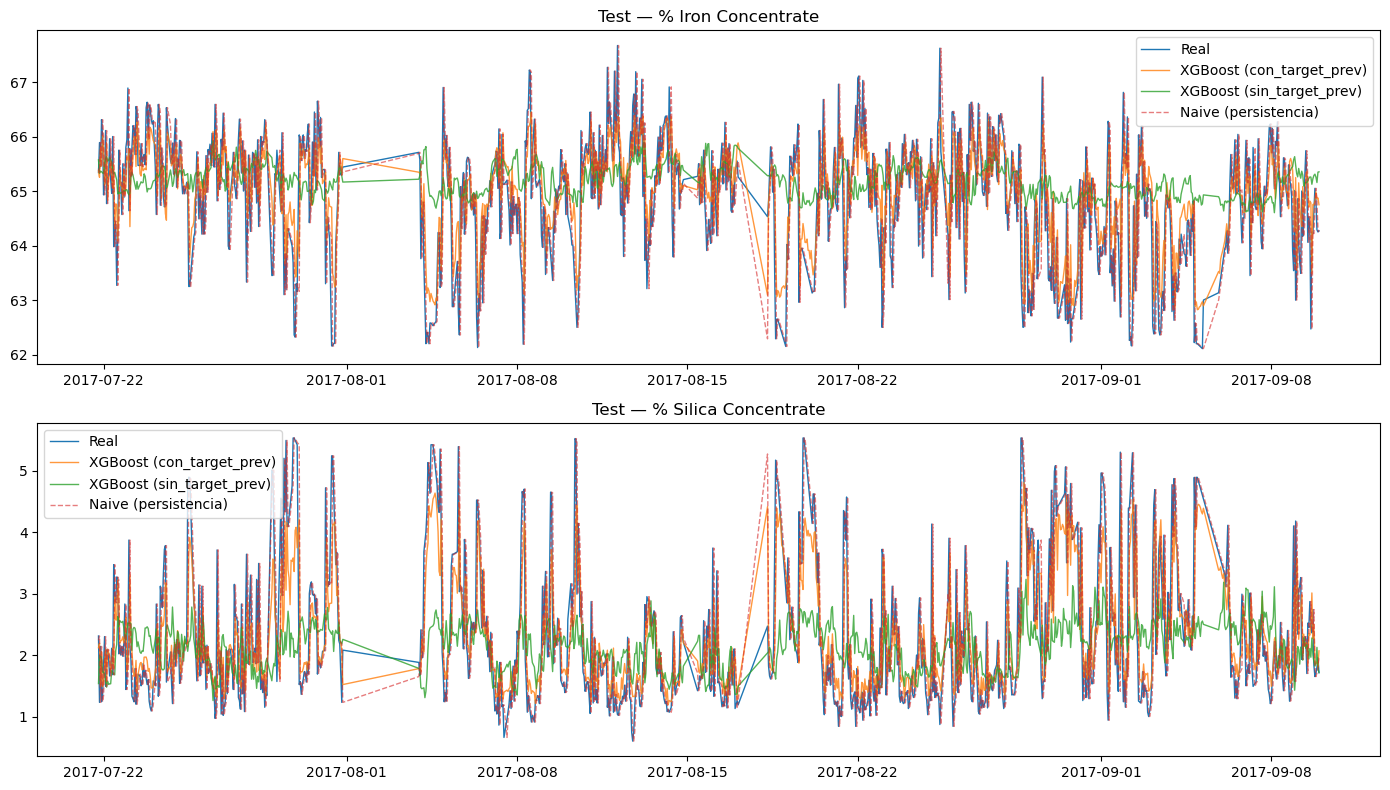

In [78]:
fig, axes = plt.subplots(len(TARGET), 1, figsize=(14, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    ax = axes[i] if len(TARGET) > 1 else axes
    ax.plot(y_test.index, y_test[col], label='Real', linewidth=1)
    for set_name, (_, y_pred_test) in predictions.items():
        ax.plot(y_pred_test.index, y_pred_test[col], label=f'XGBoost ({set_name})', linewidth=1, alpha=0.8)
    ax.plot(y_test.index, events_df.loc[y_test.index, f'target_prev_{col}'], label='Naive (persistencia)', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_title(f'Test — {col}')
    ax.legend()

plt.tight_layout()
plt.show()

## Residuales (test): con vs. sin `target_prev`, por target

Nunca solo R² — los residuales muestran si el error se concentra en algun
tramo temporal concreto (p.ej. un cambio de condiciones de proceso a partir
de cierta fecha) en vez de estar disperso de forma homogenea.

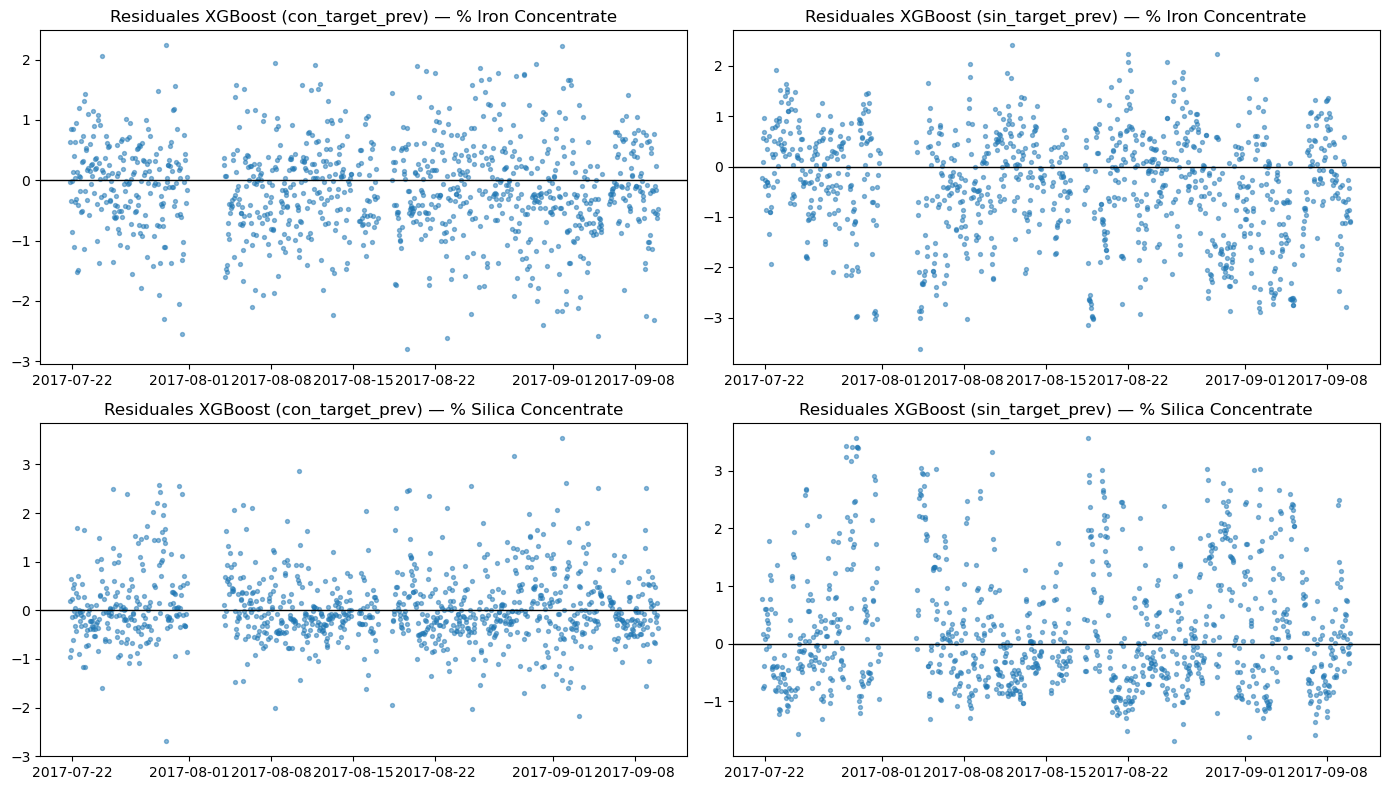

In [79]:
fig, axes = plt.subplots(len(TARGET), len(FEATURE_SETS), figsize=(7 * len(FEATURE_SETS), 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    for j, set_name in enumerate(FEATURE_SETS):
        _, y_pred_test = predictions[set_name]
        resid = y_test[col].values - y_pred_test[col].values
        ax = axes[i, j] if len(TARGET) > 1 else axes[j]
        ax.scatter(y_test.index, resid, s=8, alpha=0.5)
        ax.axhline(0, color='black', linewidth=1)
        ax.set_title(f'Residuales XGBoost ({set_name}) — {col}')

plt.tight_layout()
plt.show()

## Autocorrelacion de los residuales (con vs. sin `target_prev`)

Si los residuales del modelo tuvieran autocorrelacion significativa,
significaria que queda estructura temporal predecible que el modelo no esta
capturando (features insuficientes o mal construidas), en vez de ruido
genuino del proceso.

Los eventos no estan uniformemente espaciados en tiempo real (`gap_hours`
varia entre 1h y `GAP_MAX_HOURS`), asi que el eje de lag aqui es "numero de
eventos consecutivos", no horas — coherente con el resto del notebook, que
ya trabaja a nivel de evento y no de reloj fijo.

Se muestran ambas variantes: `con_target_prev` (el unico con señal real
segun la comparativa de RMSE) y `sin_target_prev` (para comprobar si, aun
sin batir al naive, sus residuales muestran o no estructura temporal
explotable).

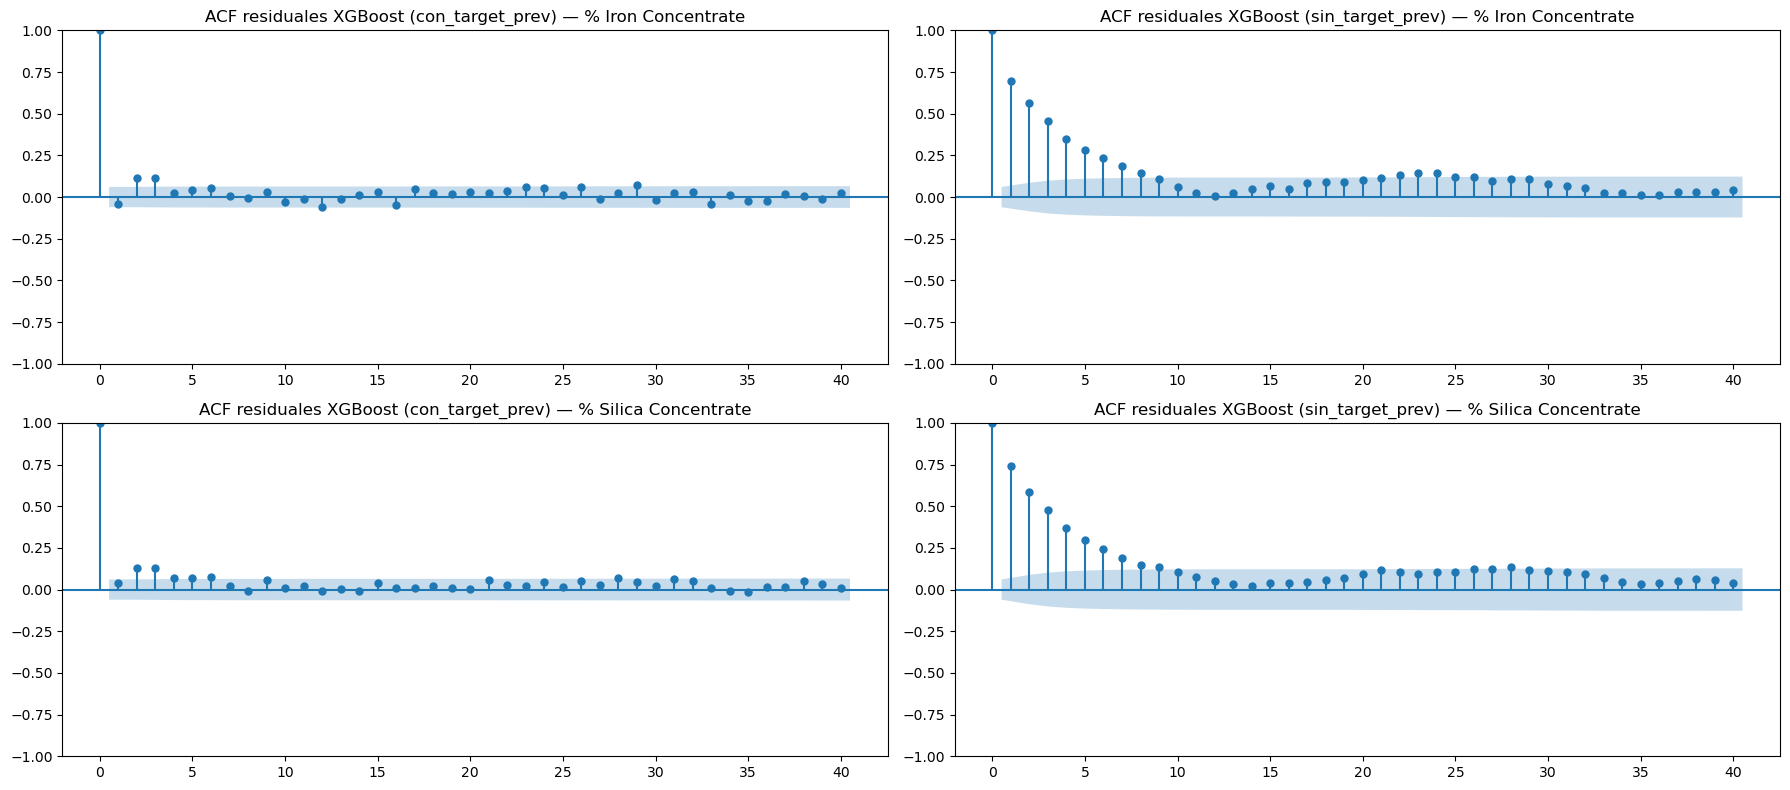

Test de Ljung-Box (lags 5, 10, 20):

=== con_target_prev ===

% Iron Concentrate
      lb_stat  lb_pvalue
5   31.834996   0.000006
10  36.879697   0.000059
20  48.866062   0.000321

% Silica Concentrate
      lb_stat     lb_pvalue
5   46.319388  7.818958e-09
10  56.299307  1.804196e-08
20  59.407831  8.791400e-06

=== sin_target_prev ===

% Iron Concentrate
        lb_stat      lb_pvalue
5   1255.313497  3.062824e-269
10  1383.833571  3.068151e-291
20  1429.009738  6.702843e-291

% Silica Concentrate
        lb_stat      lb_pvalue
5   1391.683621  8.725833e-299
10  1543.464594   0.000000e+00
20  1577.373951   0.000000e+00


In [80]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

fig, axes = plt.subplots(len(TARGET), len(FEATURE_SETS), figsize=(9 * len(FEATURE_SETS), 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    for j, set_name in enumerate(FEATURE_SETS):
        _, y_pred_test_set = predictions[set_name]
        resid = (y_test[col] - y_pred_test_set[col]).values
        ax = axes[i, j] if len(TARGET) > 1 else axes[j]
        plot_acf(resid, lags=40, ax=ax, title=f'ACF residuales XGBoost ({set_name}) — {col}')

plt.tight_layout()
plt.show()

# Test de Ljung-Box: H0 = no hay autocorrelacion hasta el lag indicado.
# p-value bajo (<0.05) => se rechaza H0 => queda estructura temporal sin explotar.
print('Test de Ljung-Box (lags 5, 10, 20):')
for set_name in FEATURE_SETS:
    _, y_pred_test_set = predictions[set_name]
    print(f'\n=== {set_name} ===')
    for col in TARGET:
        resid = (y_test[col] - y_pred_test_set[col]).values
        lb = acorr_ljungbox(resid, lags=[5, 10, 20], return_df=True)
        print(f'\n{col}')
        print(lb)

## Importancia de variables (con vs. sin `target_prev`)

`MultiOutputRegressor` entrena un `XGBRegressor` independiente por target,
asi que se reporta la importancia por separado para Iron y Silica, y por
cada variante de features. Se usa `importance_type='gain'` (ganancia media
que aporta cada feature cuando se usa en un split) en vez del conteo de
splits (`'weight'`), porque gain refleja mejor cuanto contribuye la feature
al poder predictivo del modelo, no solo cuantas veces aparece.

En `sin_target_prev` esto muestra que variable de proceso se apoya mas el
modelo una vez que no tiene disponible el valor de laboratorio anterior —
util para saber que sensores merecen mas atencion (mas lags, otra forma de
agregacion) si se quiere mejorar esa variante.

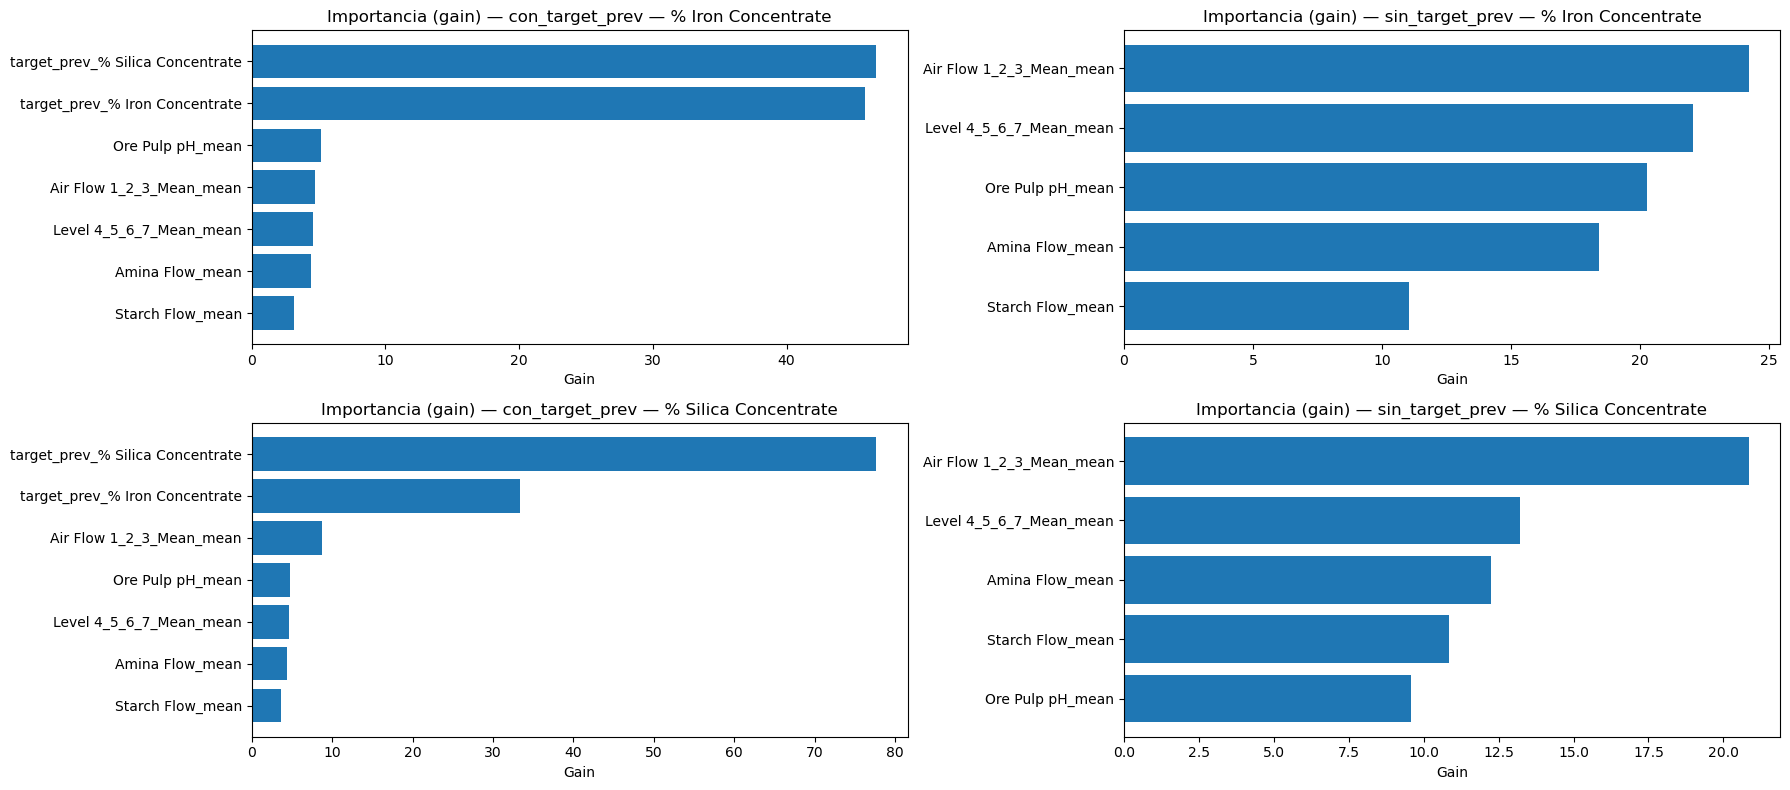


=== con_target_prev ===

Top 10 features — % Iron Concentrate (hiperparametros: {'colsample_bytree': 0.6, 'learning_rate': 0.03, 'max_depth': 2, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'subsample': 0.7})
target_prev_% Silica Concentrate    46.723949
target_prev_% Iron Concentrate      45.850693
Ore Pulp pH_mean                     5.216653
Air Flow 1_2_3_Mean_mean             4.744807
Level 4_5_6_7_Mean_mean              4.592675
Amina Flow_mean                      4.454971
Starch Flow_mean                     3.206793
Name: gain, dtype: float64

Top 10 features — % Silica Concentrate (hiperparametros: {'colsample_bytree': 0.6, 'learning_rate': 0.03, 'max_depth': 2, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'subsample': 0.9})
target_prev_% Silica Concentrate    77.659683
target_prev_% Iron Concentrate      33.309490
Air Flow 1_2_3_Mean_mean             8.779591
Ore Pulp pH_mean                     4.721959
Level 4_5_6_7_Mean_mean              4.670650
Amina Flow_mean                      4.3

In [81]:
importances = {}  # (set_name, target) -> pd.Series de gain, ordenada desc

fig, axes = plt.subplots(len(TARGET), len(FEATURE_SETS), figsize=(9 * len(FEATURE_SETS), 4 * len(TARGET)))
for j, set_name in enumerate(FEATURE_SETS):
    for i, col in enumerate(TARGET):
        estimator = fitted[set_name]['models'][col]
        booster = estimator.get_booster()
        gain_scores = booster.get_score(importance_type='gain')
        # X_train_scaled es un DataFrame, asi que XGBoost ya usa los nombres reales
        # de columna como feature names en el booster (no f0..fN generico).
        imp = pd.Series(gain_scores, name='gain').sort_values(ascending=False)
        importances[(set_name, col)] = imp

        ax = axes[i, j] if len(TARGET) > 1 else axes[j]
        top_n = imp.head(15)
        ax.barh(top_n.index[::-1], top_n.values[::-1])
        ax.set_title(f'Importancia (gain) — {set_name} — {col}')
        ax.set_xlabel('Gain')

plt.tight_layout()
plt.show()

for set_name in FEATURE_SETS:
    print(f'\n=== {set_name} ===')
    for col in TARGET:
        print(f'\nTop 10 features — {col} (hiperparametros: {fitted[set_name]["best_params"][col]})')
        print(importances[(set_name, col)].head(10))

## Caracterizacion de saltos grandes vs. normales en los targets

Pregunta distinta a la de prediccion punto a punto: ¿que aspecto tienen las
variables de proceso (agregadas por ventana) cuando el evento que sigue es un
salto grande en el target, comparado con un evento de cambio "normal"?

Como `events_df` tiene **dos targets** (`% Iron Concentrate` y
`% Silica Concentrate`), el analisis se repite una vez por target en vez de
asumir una unica columna `target`/`target_prev`:

- `abs_change_{target}` = `|target_{target} - target_prev_{target}|`
- "Extremos" = eventos en el percentil 90 superior de `abs_change` para ese
  target; "normales" = el resto.
- Para cada feature agregada (`_mean`, `_std`, `_slope` de cada sensor), test
  de Mann-Whitney (no asume normalidad, robusto a outliers) entre extremos y
  normales, mas un tamaño de efecto (diferencia de medias / std del grupo
  normal).
- Se excluyen de las features candidatas las columnas de target (`target_*`)
  y `gap_hours` (metadato de filtrado, no variable de proceso).

p-value bajo + effect_size grande ⇒ esa variable de proceso se comporta de
forma distinta justo antes de un salto grande, y es candidata a investigar
(o a añadir como feature de "riesgo de salto") ademas de su uso en la
regresion punto a punto de mas arriba.

In [82]:
from scipy import stats

# Columnas candidatas: todas las features agregadas de sensores, excluyendo
# targets (en cualquiera de sus variantes _prev/actual) y gap_hours.
excluded_cols = {c for c in events_df.columns if c.startswith('target_') or c.startswith('target_prev_')}
excluded_cols.add('gap_hours')
sensor_feature_cols = [c for c in events_df.columns if c not in excluded_cols]

print(f"Features candidatas ({len(sensor_feature_cols)}): {sensor_feature_cols}")

jump_results = {}  # target -> results_df ordenado por p_value

for target in TARGET:
    abs_change = (events_df[f'target_{target}'] - events_df[f'target_prev_{target}']).abs()
    threshold = abs_change.quantile(0.90)

    extreme_mask = abs_change >= threshold
    extreme_events = events_df.loc[extreme_mask]
    normal_events = events_df.loc[~extreme_mask]

    results = []
    for col in sensor_feature_cols:
        extreme_vals = extreme_events[col].dropna()
        normal_vals = normal_events[col].dropna()
        if len(extreme_vals) < 10 or len(normal_vals) < 10:
            continue
        stat, pval = stats.mannwhitneyu(extreme_vals, normal_vals, alternative='two-sided')
        effect_size = (extreme_vals.mean() - normal_vals.mean()) / normal_vals.std()
        results.append({'feature': col, 'p_value': pval, 'effect_size': effect_size,
                         'n_extreme': len(extreme_vals), 'n_normal': len(normal_vals)})

    results_df = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
    jump_results[target] = dict(results_df=results_df, threshold=threshold,
                                 extreme_events=extreme_events, normal_events=normal_events)

    print(f"\n=== {target} — umbral salto (p90 de |cambio|) = {threshold:.4f} — "
          f"{len(extreme_events)} extremos vs {len(normal_events)} normales ===")
    print(results_df.head(15).to_string(index=False))

Features candidatas (33): ['Starch Flow_mean', 'Starch Flow_std', 'Starch Flow_slope', 'Amina Flow_mean', 'Amina Flow_std', 'Amina Flow_slope', 'Ore Pulp Flow_mean', 'Ore Pulp Flow_std', 'Ore Pulp Flow_slope', 'Ore Pulp pH_mean', 'Ore Pulp pH_std', 'Ore Pulp pH_slope', 'Ore Pulp Density_mean', 'Ore Pulp Density_std', 'Ore Pulp Density_slope', 'Flotation Column 04 Air Flow_mean', 'Flotation Column 04 Air Flow_std', 'Flotation Column 04 Air Flow_slope', 'Flotation Column 05 Air Flow_mean', 'Flotation Column 05 Air Flow_std', 'Flotation Column 05 Air Flow_slope', 'Air Flow 6_7_Mean_mean', 'Air Flow 6_7_Mean_std', 'Air Flow 6_7_Mean_slope', 'Air Flow 1_2_3_Mean_mean', 'Air Flow 1_2_3_Mean_std', 'Air Flow 1_2_3_Mean_slope', 'Level 4_5_6_7_Mean_mean', 'Level 4_5_6_7_Mean_std', 'Level 4_5_6_7_Mean_slope', 'Level 1_2_3_Mean_mean', 'Level 1_2_3_Mean_std', 'Level 1_2_3_Mean_slope']

=== % Iron Concentrate — umbral salto (p90 de |cambio|) = 1.4000 — 346 extremos vs 3100 normales ===
             

### Vista global: significancia vs. tamaño de efecto

Cada punto es una feature agregada. Eje X = effect_size (cuanto mas lejos de
0, mas distinta es la media en extremos vs. normales, en unidades de std del
grupo normal); eje Y = -log10(p_value) (cuanto mas alto, mas significativo).
Linea horizontal discontinua = umbral de significancia (p=0.05). Las features
en la esquina superior-derecha/izquierda (alto -log10(p), |effect_size|
grande) son las que mejor separan saltos grandes de cambios normales.

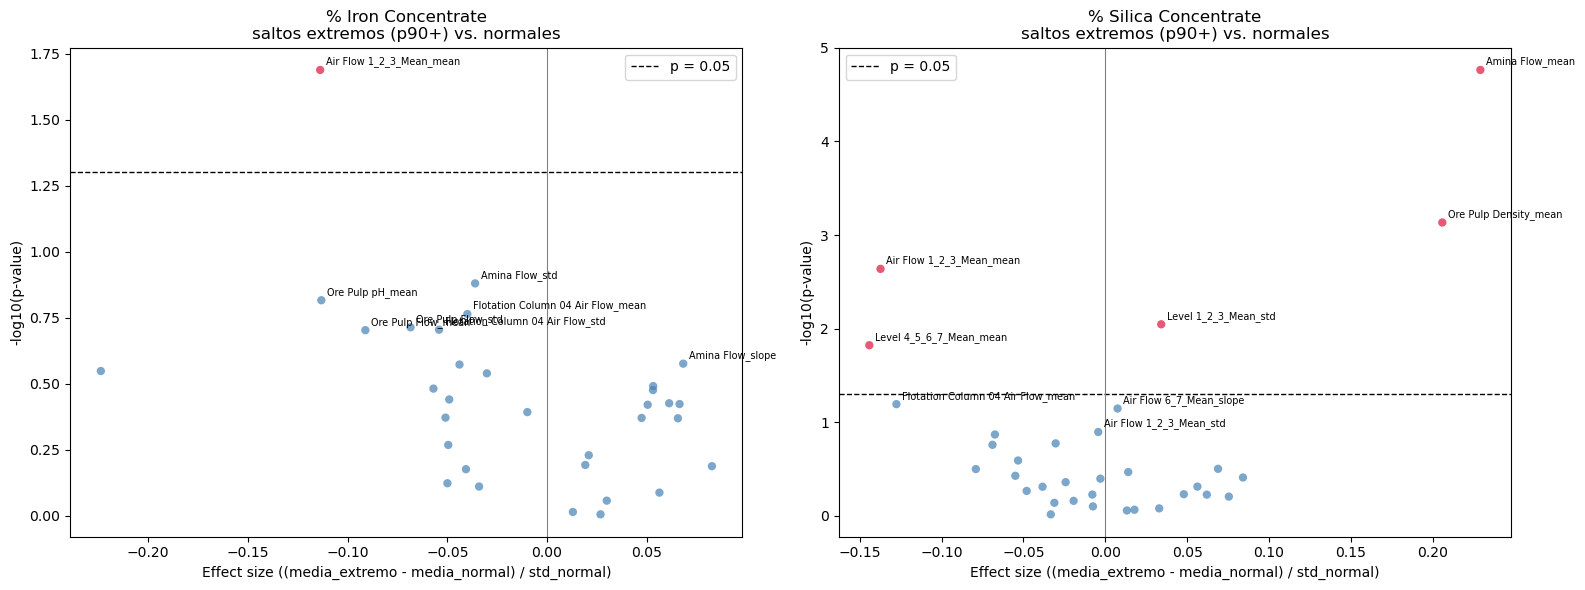

In [83]:
fig, axes = plt.subplots(1, len(TARGET), figsize=(8 * len(TARGET), 6))
for i, target in enumerate(TARGET):
    results_df = jump_results[target]['results_df']
    ax = axes[i] if len(TARGET) > 1 else axes

    neg_log_p = -np.log10(results_df['p_value'].clip(lower=1e-300))
    colors = np.where(results_df['p_value'] < 0.05, 'crimson', 'steelblue')

    ax.scatter(results_df['effect_size'], neg_log_p, c=colors, alpha=0.7, edgecolor='none')
    ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=1, label='p = 0.05')
    ax.axvline(0, color='grey', linewidth=0.8)

    # Etiqueta las top-8 features por p-value para no saturar el grafico
    for _, row in results_df.head(8).iterrows():
        ax.annotate(row['feature'], (row['effect_size'], -np.log10(max(row['p_value'], 1e-300))),
                    fontsize=7, xytext=(4, 4), textcoords='offset points')

    ax.set_xlabel('Effect size ((media_extremo - media_normal) / std_normal)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'{target}\nsaltos extremos (p90+) vs. normales')
    ax.legend()

plt.tight_layout()
plt.show()

### Distribucion detallada: top features por target

Boxplots (extremos vs. normales) de las features con menor p-value para
cada target — la forma mas directa de ver *como* difiere la distribucion
(desplazamiento de mediana, dispersion, colas), no solo el resumen numerico
de la tabla.

In [100]:
import seaborn as sns

TOP_N = 15

for target in TARGET:
    info = jump_results[target]
    # top_features = info['results_df'].head(TOP_N)['feature'].tolist()

    # En vez de top 5 por p-valor horario, usa TODAS las columnas de sensor crudas
    all_sensor_cols = [c for c in df.columns if c not in TARGET and c != "date"]  # ajusta si hay columnas auxiliares
    top_features = all_sensor_cols

    plot_rows = []
    for col in top_features:
        for label, subset in [('extremo', info['extreme_events']), ('normal', info['normal_events'])]:
            for val in subset[col].dropna():
                plot_rows.append({'feature': col, 'grupo': label, 'valor': val})
    plot_df = pd.DataFrame(plot_rows)

    g = sns.catplot(
        data=plot_df, x='grupo', y='valor', col='feature', hue='grupo',
        kind='box', col_wrap=3, sharey=False, height=3.2, aspect=1.1,
        palette={'extremo': 'crimson', 'normal': 'steelblue'}, legend=False,
    )
    g.set_titles('{col_name}')
    g.figure.suptitle(f'{target} — top {TOP_N} features (saltos extremos vs. normales)', y=1.03)
    plt.show()

KeyError: 'Starch Flow'

## Comportamiento a resolucion cruda (20s) antes de un salto

El analisis anterior compara **agregados por hora** (media/std/pendiente)
entre eventos extremos y normales. Aqui bajamos a la resolucion original de
muestreo (20s) para ver la **forma real de la señal** de las features mas
caracteristicas, en la ventana `(evento_anterior, evento_actual]` — es decir,
la hora del evento y, cuando el gap lo permite, la hora anterior — en vez de
solo su resumen numerico.

Objetivo: comprobar si hay un patron visible (oscilacion, cambio de
pendiente, cambio de nivel) que preceda a un salto grande, no solo una media
distinta.

Para cada target:
1. Se seleccionan los `TOP_N_EVENTS` eventos con menor p-value / mayor
   `|effect_size|` de la feature mas significativa (de la tabla ya calculada
   en `jump_results`).
2. Se comparan contra el mismo numero de eventos "normales" elegidos al azar
   (semilla fija, para reproducibilidad).
3. Se grafica la serie cruda de 20s de esa feature durante la ventana
   `(prev_time, event_time]` de cada evento, alineando el eje X en **horas
   relativas al evento** (0 = instante del salto) para poder superponer
   varios eventos de duracion distinta.

In [ ]:
TOP_N_EVENTS = 8
RANDOM_SEED = 21
LOOKBACK_HOURS = 2  # cuanta historia adicional mostrar antes de prev_time, solo para contexto visual

# events_df no guarda prev_time explicitamente (solo gap_hours); se reconstruye
# porque df_hourly es estrictamente horario, asi que prev_time = event_time - gap_hours.
event_prev_time = events_df.index - pd.to_timedelta(events_df['gap_hours'], unit='h')

def raw_window(col, prev_time, event_time, lookback_hours=0):
    """Serie cruda de 20s de `col` en df, desde (prev_time - lookback) hasta event_time."""
    start = prev_time - pd.Timedelta(hours=lookback_hours)
    return df.loc[start:event_time, col]

rng = np.random.default_rng(RANDOM_SEED)

raw_signal_info = {}  # target -> dict con top_feature, top_event_times, normal_event_times

# print el número de filas en df
print(f"df (resolucion 20s, post-limpieza): {len(df)} filas, rango {df.index.min()} -> {df.index.max()}")

for target in TARGET:
    results_df = jump_results[target]['results_df']
    top_feature = results_df.iloc[0]['feature'].rsplit('_', 1)[0]  # quita sufijo _mean/_std/_slope -> columna cruda en df
    print(f"\n=== {target} — feature mas significativa = '{top_feature}' ===")
    if not top_feature in df.columns:
        print(f"Advertencia: la feature mas significativa '{top_feature}' para {target} no existe en df.columns, se omite.")
        continue

    abs_change = (events_df[f'target_{target}'] - events_df[f'target_prev_{target}']).abs()
    threshold = jump_results[target]['threshold']

    extreme_idx = abs_change[abs_change >= threshold].sort_values(ascending=False).index
    top_event_times = extreme_idx[:TOP_N_EVENTS]

    normal_idx = abs_change[abs_change < threshold].index
    normal_event_times = pd.DatetimeIndex(rng.choice(normal_idx, size=min(TOP_N_EVENTS, len(normal_idx)), replace=False))

    raw_signal_info[target] = dict(top_feature=top_feature, top_event_times=top_event_times,
                                    normal_event_times=normal_event_times)

    print(f"{target}: feature mas significativa = '{top_feature}' "
          f"(p={results_df.iloc[0]['p_value']:.2e}, effect_size={results_df.iloc[0]['effect_size']:.3f})")
    print(f"  top {len(top_event_times)} eventos extremos: {list(top_event_times)}")

df (resolucion 20s, post-limpieza): 710639 filas, rango 2017-03-29 12:00:00 -> 2017-09-09 23:59:40

=== % Iron Concentrate — feature mas significativa = 'Air Flow 1_2_3_Mean' ===
% Iron Concentrate: feature mas significativa = 'Air Flow 1_2_3_Mean' (p=2.05e-02, effect_size=-0.114)
  top 8 eventos extremos: [Timestamp('2017-07-01 01:00:00'), Timestamp('2017-07-06 07:00:00'), Timestamp('2017-04-22 19:00:00'), Timestamp('2017-07-07 21:00:00'), Timestamp('2017-08-19 14:00:00'), Timestamp('2017-07-14 03:00:00'), Timestamp('2017-04-28 18:00:00'), Timestamp('2017-04-21 07:00:00')]

=== % Silica Concentrate — feature mas significativa = 'Amina Flow' ===
% Silica Concentrate: feature mas significativa = 'Amina Flow' (p=1.73e-05, effect_size=0.229)
  top 8 eventos extremos: [Timestamp('2017-03-29 16:00:00'), Timestamp('2017-07-30 01:00:00'), Timestamp('2017-09-01 19:00:00'), Timestamp('2017-03-29 17:00:00'), Timestamp('2017-06-07 20:00:00'), Timestamp('2017-07-19 22:00:00'), Timestamp('2017-07-1

### Series superpuestas: extremos vs. normales (alineadas al instante del salto)

Cada linea es un evento individual (20s/muestra), con el eje X en horas
relativas al evento (0 = `event_time`, valores negativos = antes del salto).
La linea negra gruesa es la mediana punto a punto de los eventos extremos, y
la linea gris discontinua la mediana de los normales, para ver la tendencia
comun sin que las curvas individuales la tapen.

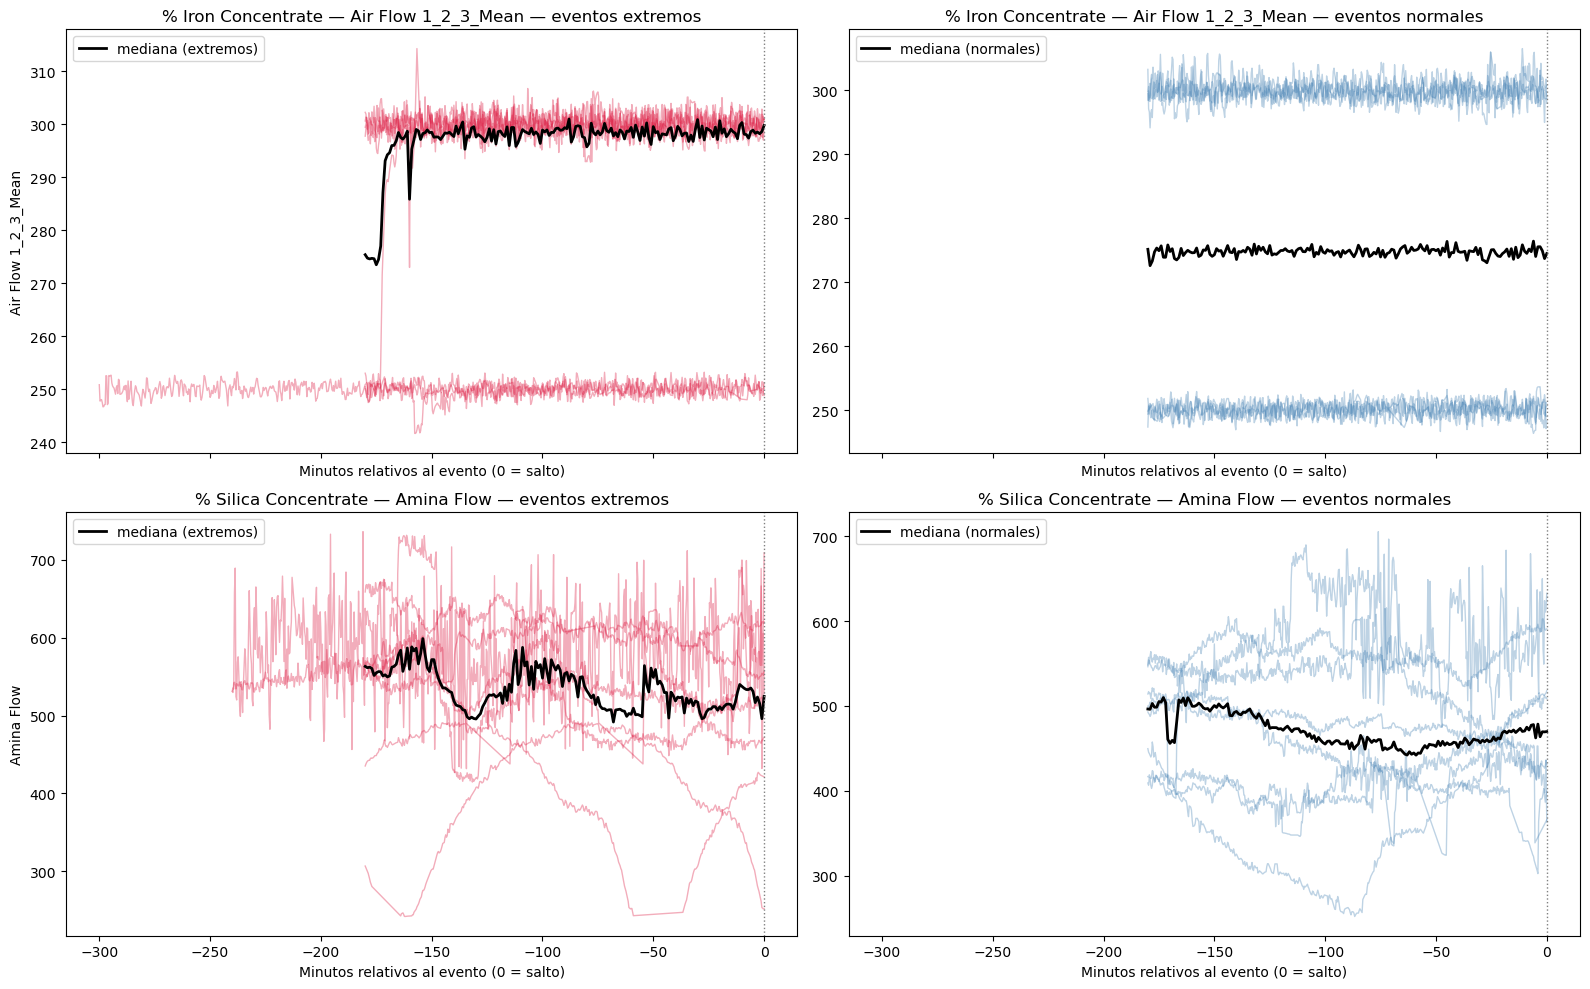

In [ ]:
GRID_MINUTES = np.arange(-(LOOKBACK_HOURS * 60 + 60), 1, 1)  # rejilla comun, en minutos relativos al evento (paso 1 min)

def to_relative_grid(series, event_time):
    """Reindexa `series` (irregular, 20s) a `GRID_MINUTES` relativos al evento,
    interpolando linealmente -- necesario para poder calcular una mediana
    punto a punto entre eventos de duracion/gap distintos."""
    rel_minutes = (series.index - event_time).total_seconds() / 60
    s = pd.Series(series.values, index=rel_minutes).sort_index()
    s = s[~s.index.duplicated(keep='first')]
    return s.reindex(s.index.union(GRID_MINUTES)).interpolate(limit_area='inside').reindex(GRID_MINUTES)

fig, axes = plt.subplots(len(TARGET), 2, figsize=(16, 5 * len(TARGET)), sharex=True)

for i, target in enumerate(TARGET):
    info = raw_signal_info[target]
    feature = info['top_feature']

    for j, (label, event_times, color) in enumerate([
        ('extremos', info['top_event_times'], 'crimson'),
        ('normales', info['normal_event_times'], 'steelblue'),
    ]):
        ax = axes[i, j]
        aligned = []
        for event_time in event_times:
            prev_time = event_prev_time.loc[event_time]
            raw = raw_window(feature, prev_time, event_time, lookback_hours=LOOKBACK_HOURS)
            if raw.empty:
                continue
            ax.plot((raw.index - event_time).total_seconds() / 60, raw.values,
                    color=color, alpha=0.35, linewidth=1)
            aligned.append(to_relative_grid(raw, event_time))

        if aligned:
            median_curve = pd.concat(aligned, axis=1).median(axis=1)
            ax.plot(GRID_MINUTES, median_curve.values, color='black', linewidth=2, label=f'mediana ({label})')

        ax.axvline(0, color='grey', linestyle=':', linewidth=1)
        ax.set_title(f'{target} — {feature} — eventos {label}')
        ax.set_xlabel('Minutos relativos al evento (0 = salto)')
        ax.legend()

    axes[i, 0].set_ylabel(feature)

plt.tight_layout()
plt.show()

### Cuantificando la forma de la señal: oscilacion, cambio de pendiente, cambio de nivel

El grafico anterior es cualitativo. Aqui se calculan tres metricas por evento
sobre la ventana `(prev_time, event_time]` a 20s, partiendo la ventana en dos
mitades para poder hablar de "antes" vs. "justo antes del salto":

- **oscilacion** = desviacion estandar de la derivada (`diff()`) de toda la
  ventana — alta si la señal vibra mucho en vez de moverse suave.
- **cambio de pendiente** = pendiente (regresion lineal) de la 2ª mitad menos
  la de la 1ª mitad — distinto de cero si la señal acelera/frena justo antes
  del evento.
- **cambio de nivel** = media de la 2ª mitad menos media de la 1ª mitad — un
  desplazamiento de nivel dentro de la propia ventana.

Se comparan extremos vs. normales con Mann-Whitney, igual que en el analisis
horario, para saber si alguna de estas tres formas de "comportamiento
peculiar" es estadisticamente distinguible antes de un salto.

In [ ]:
SHAPE_TOP_N_FEATURES = 5  # cuantas features top (por p-value horario) caracterizar a 20s

def shape_metrics(raw):
    """oscilacion, cambio de pendiente y cambio de nivel de una ventana cruda a 20s."""
    vals = raw.values.astype(float)
    n = len(vals)
    if n < 6:  # necesita al menos un puñado de puntos en cada mitad para que la pendiente tenga sentido
        print(f"Advertencia: ventana demasiado corta ({n} puntos) para calcular shape_metrics, se omite.")
        return None

    diffs = np.diff(vals)
    oscillation = np.nanstd(diffs)

    half = n // 2
    x1, x2 = np.arange(half), np.arange(n - half)
    v1, v2 = vals[:half], vals[half:]

    valid1, valid2 = ~np.isnan(v1), ~np.isnan(v2)
    slope1 = np.polyfit(x1[valid1], v1[valid1], 1)[0] if valid1.sum() > 1 else np.nan
    slope2 = np.polyfit(x2[valid2], v2[valid2], 1)[0] if valid2.sum() > 1 else np.nan

    return dict(oscillation=oscillation, slope_change=slope2 - slope1,
                level_change=np.nanmean(v2) - np.nanmean(v1))

shape_results = {}  # target -> results_df (Mann-Whitney sobre las 3 metricas de forma, para las top features)

for target in TARGET:
    results_df = jump_results[target]['results_df']
    top_features = [f.rsplit('_', 1)[0] for f in results_df.head(SHAPE_TOP_N_FEATURES)['feature']]
    top_features = list(dict.fromkeys(top_features))  # dedup preservando orden (mean/std/slope de la misma col)

    abs_change = (events_df[f'target_{target}'] - events_df[f'target_prev_{target}']).abs()
    threshold = jump_results[target]['threshold']
    extreme_events_idx = abs_change[abs_change >= threshold].index
    normal_events_idx = abs_change[abs_change < threshold].index

    rows = []
    for feature in top_features:
        for label, idx_set in [('extremo', extreme_events_idx), ('normal', normal_events_idx)]:
            for event_time in idx_set:
                prev_time = event_prev_time.loc[event_time]
                raw = raw_window(feature, prev_time, event_time)
                metrics = shape_metrics(raw)
                if metrics is None:
                    print(f"Advertencia: no se pudieron calcular shape_metrics para feature '{feature}' en evento {event_time}, se omite.")
                    continue
                rows.append(dict(feature=feature, grupo=label, event_time=event_time, **metrics))

    shape_df = pd.DataFrame(rows)

    test_rows = []
    for feature in top_features:
        feat_df = shape_df[shape_df['feature'] == feature]
        extreme_vals = feat_df[feat_df['grupo'] == 'extremo']
        normal_vals = feat_df[feat_df['grupo'] == 'normal']
        for metric in ['oscillation', 'slope_change', 'level_change']:
            e = extreme_vals[metric].dropna()
            n = normal_vals[metric].dropna()
            if len(e) < 10 or len(n) < 10:
                continue
            stat, pval = stats.mannwhitneyu(e, n, alternative='two-sided')
            effect = (e.mean() - n.mean()) / n.std() if n.std() > 0 else np.nan
            test_rows.append(dict(feature=feature, metric=metric, p_value=pval, effect_size=effect,
                                   mean_extremo=e.mean(), mean_normal=n.mean()))

    shape_results[target] = dict(shape_df=shape_df, test_df=pd.DataFrame(test_rows).sort_values('p_value'))

    print(f"\n=== {target} — metricas de forma (20s) en top {len(top_features)} features ===")
    print(shape_results[target]['test_df'].to_string(index=False))


=== % Iron Concentrate — metricas de forma (20s) en top 5 features ===
                     feature       metric  p_value  effect_size  mean_extremo  mean_normal
                  Amina Flow slope_change 0.030811     0.100848      0.049265    -0.044086
                 Ore Pulp pH  oscillation 0.061570     0.495122      0.002259     0.001511
                 Ore Pulp pH slope_change 0.197135     0.088913      0.000150    -0.000029
Flotation Column 04 Air Flow level_change 0.233536    -0.044151     -0.007077     0.002566
Flotation Column 04 Air Flow slope_change 0.321032    -0.030664     -0.000115     0.000084
         Air Flow 1_2_3_Mean  oscillation 0.330850     0.065916      1.453640     1.419504
                  Amina Flow  oscillation 0.363864    -0.065349      8.582809     9.284581
               Ore Pulp Flow slope_change 0.381273    -0.007143     -0.000763     0.000100
               Ore Pulp Flow level_change 0.506750    -0.050356     -0.229738    -0.007230
                  

### Boxplots de las metricas de forma: ¿los normales tambien oscilan?

Para responder directamente si los eventos "normales" muestran o no algo de
variacion en estas metricas (o si el comportamiento peculiar es exclusivo de
los saltos grandes), se grafican lado a lado extremo vs. normal para la
feature con menor p-value de cada target, una fila por metrica.

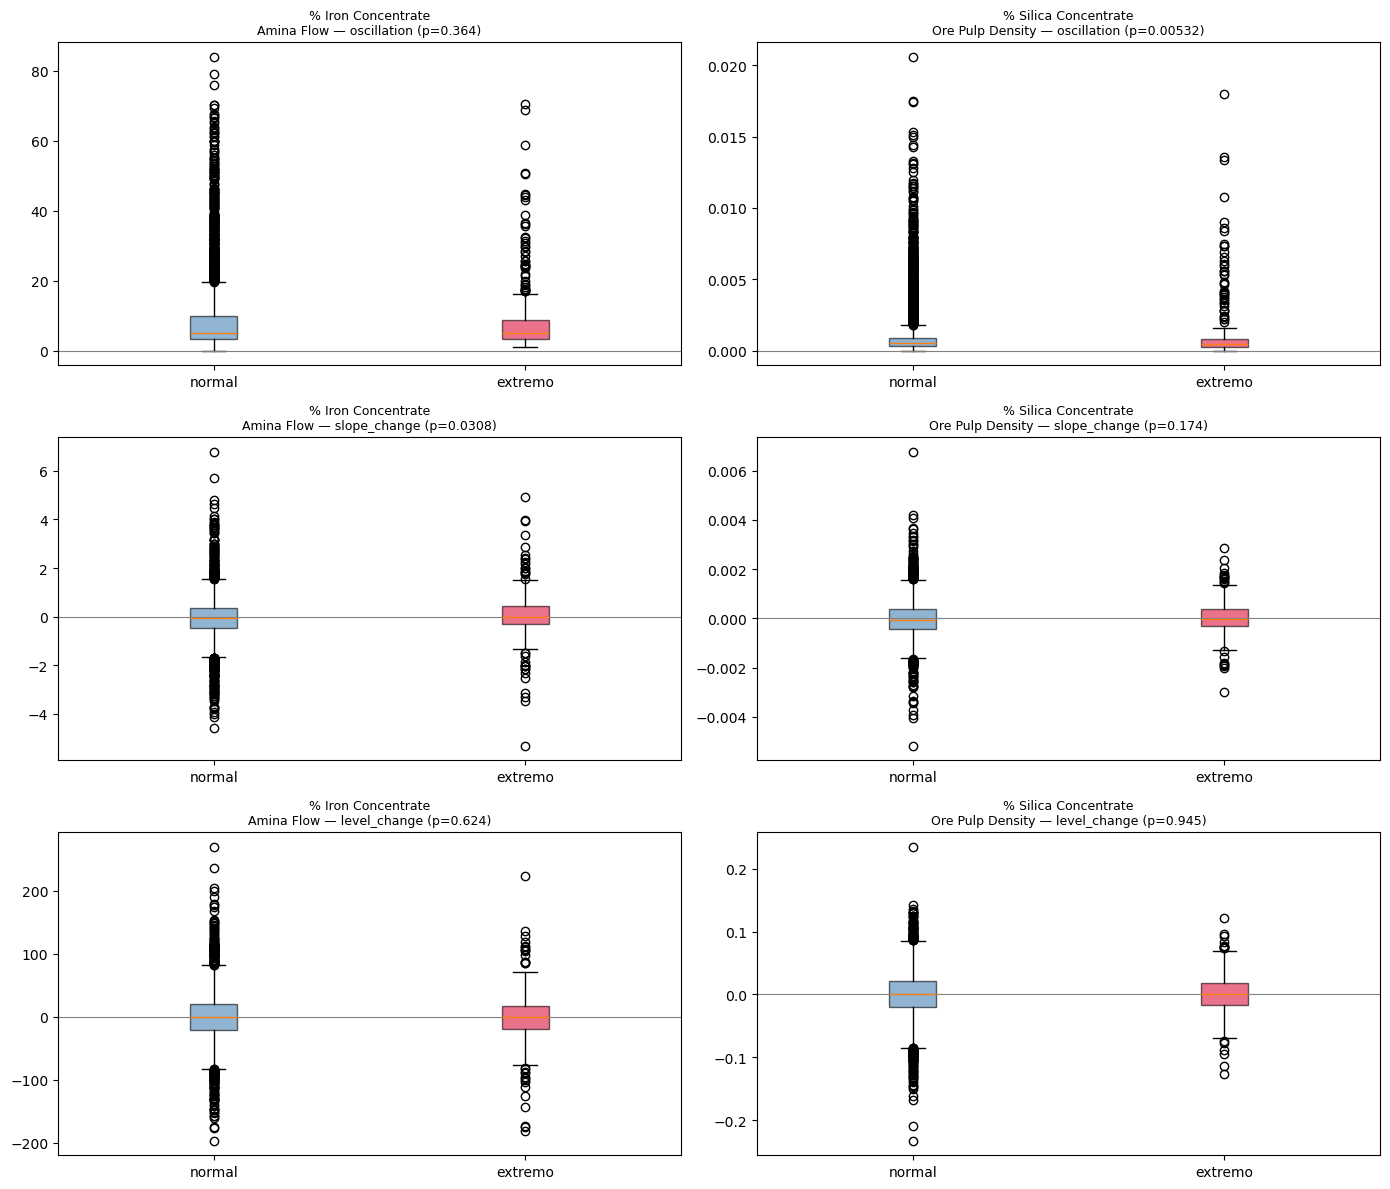

In [ ]:
metrics = ['oscillation', 'slope_change', 'level_change']

fig, axes = plt.subplots(len(metrics), len(TARGET), figsize=(7 * len(TARGET), 4 * len(metrics)))

for j, target in enumerate(TARGET):
    shape_df = shape_results[target]['shape_df']
    test_df = shape_results[target]['test_df']
    # feature mas significativa en el test de forma (no necesariamente la misma que en el analisis horario)
    top_shape_feature = test_df.iloc[0]['feature'] if len(test_df) else shape_df['feature'].iloc[0]
    feat_df = shape_df[shape_df['feature'] == top_shape_feature]

    for i, metric in enumerate(metrics):
        ax = axes[i, j] if len(TARGET) > 1 else axes[i]
        data = [feat_df.loc[feat_df['grupo'] == g, metric].dropna() for g in ['normal', 'extremo']]
        bp = ax.boxplot(data, tick_labels=['normal', 'extremo'], patch_artist=True)
        for patch, color in zip(bp['boxes'], ['steelblue', 'crimson']):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        row = test_df[(test_df['feature'] == top_shape_feature) & (test_df['metric'] == metric)]
        p_str = f"p={row.iloc[0]['p_value']:.3g}" if len(row) else "n/a"
        ax.set_title(f'{target}\n{top_shape_feature} — {metric} ({p_str})', fontsize=9)
        ax.axhline(0, color='grey', linewidth=0.8)

plt.tight_layout()
plt.show()